In [532]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Problem Formulation

    Laptop Price Prediction based on Several Features

# 2. Data Collection

    We have sample laptop dataset in csv format
    

# 3. Reading & Understanding Data
- Load dataset (pandas, numpy).
- Check df.head(), df.info(), df.shape, df.describe() to get a feel for it.
- Identify data types (numeric, categorical, text, dates).


In [533]:
df = pd.read_csv("laptop_sample_data.csv")
df.head()

,product_id,Brand,Ram,Storage,Display,Touch,Color,Build_quality,OS,Price
0,1,Dell,16GB,512GB SSD,15.6 inch,No,Black,Fair,Windows,521.51
1,2,Dell,8GB,256GB SSD,15.6 inch,Yes,Gray,Excellent,MacOS,2377.26
2,3,HP,16GB,1TB SSD,16 inch,Yes,Gray,Excellent,Windows,1091.66
3,4,Lenovo,16GB,256GB SSD,13.3 inch,Yes,Black,Fair,Linux,2314.08
4,5,Apple,16GB,1TB SSD,15.6 inch,Yes,NaN,Fair,MacOS,1265.25


In [534]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   product_id     30 non-null     int64  
 1   Brand          30 non-null     object 
 2   Ram            30 non-null     object 
 3   Storage        30 non-null     object 
 4   Display        30 non-null     object 
 5   Touch          30 non-null     object 
 6   Color          27 non-null     object 
 7   Build_quality  30 non-null     object 
 8   OS             30 non-null     object 
 9   Price          30 non-null     float64
dtypes: float64(1), int64(1), object(8)
memory usage: 2.5+ KB


In [535]:
df.columns

Index(['product_id', 'Brand', 'Ram', 'Storage', 'Display', 'Touch', 'Color',
       'Build_quality', 'OS', 'Price'],
      dtype='object')

In [536]:
df.shape # Rows, Columns

(30, 10)

In [537]:
df.describe()

,product_id,Price
count,30.000000,30.000000
mean,15.500000,1539.830667
std,8.803408,633.882178
min,1.000000,445.080000
25%,8.250000,996.087500
50%,15.500000,1668.490000
75%,22.750000,2083.575000
max,30.000000,2413.670000


# 4. EDA (Exploratory Data Analysis) & Handling Missing Values
- Visualize distributions (hist, boxplot, pairplot).
- Detect missing values (df.isnull().sum()), outliers, skewness.
- Handle missing values by:
- Drop (if very few rows missing).
- Impute (mean, median, mode, forward fill).


#### Replace column spaces  if any

In [538]:

df.columns = df.columns.str.replace(" ", "_")

    df.drop("product_id",axis=1, inplace=True)

### Checking for missing values

In [539]:
df.isnull().sum()

product_id       0
Brand            0
Ram              0
Storage          0
Display          0
Touch            0
Color            3
Build_quality    0
OS               0
Price            0
dtype: int64

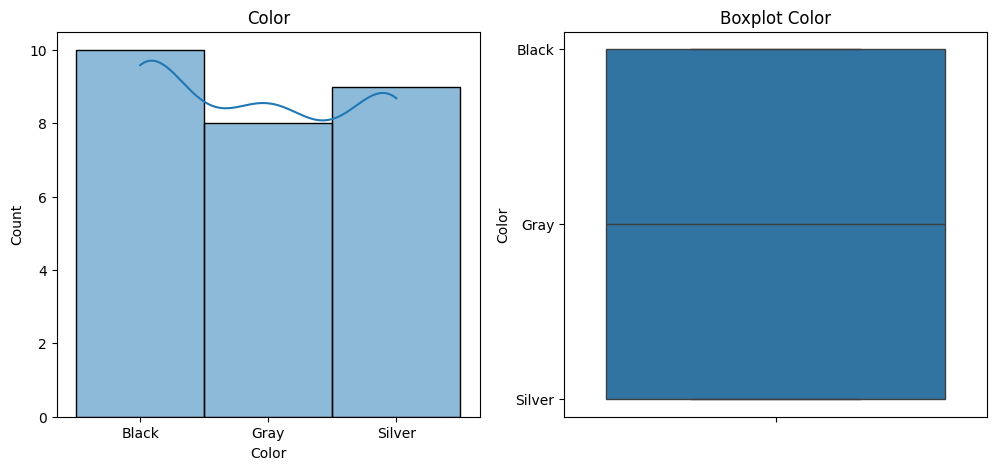

In [540]:
## filling missing values of Color
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df["Color"], kde=True)
plt.title("Color")


plt.subplot(1,2,2)
sns.boxplot(df["Color"])
plt.title("Boxplot Color")
plt.show()

In [541]:
color_mod = df["Color"].mode()[0]


In [542]:
df["Color"].fillna(color_mod, inplace=True)

C:\Users\aabidkhokhar\AppData\Local\Temp\ipykernel_5848\2243684777.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Color"].fillna(color_mod, inplace=True)


In [543]:
df["Color"].isnull().sum()

np.int64(0)

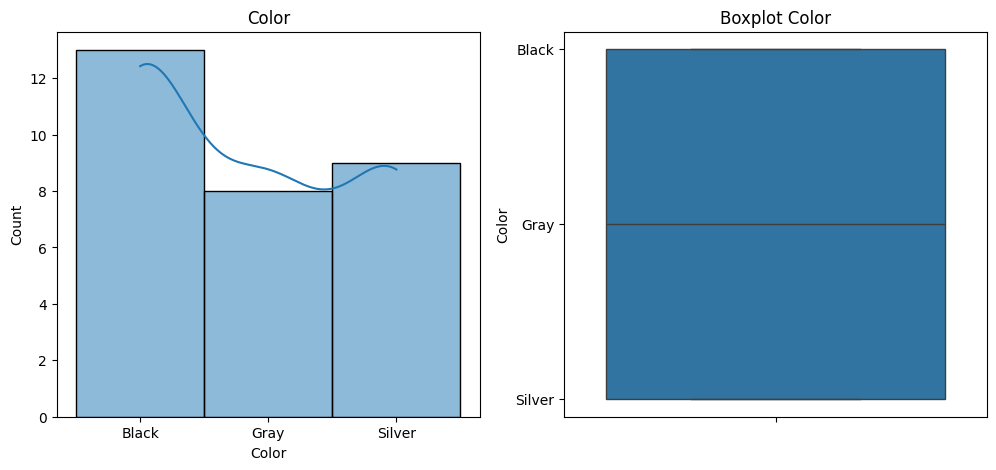

In [544]:
## filling missing values of Color
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df["Color"], kde=True)
plt.title("Color")


plt.subplot(1,2,2)
sns.boxplot(df["Color"])
plt.title("Boxplot Color")
plt.show()

# 5. Encoding (for categorical data)
- Convert non-numeric features into numeric form.
- Techniques:
    - Label Encoding (ordered categories).
    - One-Hot / Dummy Variables (unordered).
    - Binary Encoding (Yes/No → 1/0).


In [ ]:
df.head(2) 

,product_id,Brand,Ram,Storage,Display,Touch,Color,Build_quality,OS,Price
0,1,Dell,16GB,512GB SSD,15.6 inch,No,Black,Fair,Windows,521.51
1,2,Dell,8GB,256GB SSD,15.6 inch,Yes,Gray,Excellent,MacOS,2377.26


### One Hot Encoding

In [546]:
df["Brand"].unique()

array(['Dell', 'HP', 'Lenovo', 'Apple', 'Asus', 'Acer'], dtype=object)

In [547]:
encoded_brand = pd.get_dummies(df["Brand"], prefix="Brand", drop_first=True) #, 
df.drop("Brand", axis=1, inplace=True) # drop the original column
encoded_brand.head(1)


,Brand_Apple,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo
0,False,False,True,False,False


In [548]:
df["Color"].unique()

array(['Black', 'Gray', 'Silver'], dtype=object)

In [549]:
encoded_color = pd.get_dummies(df["Color"], prefix="Color", drop_first=True) #, 
df.drop("Color", axis=1, inplace=True) # drop the original column
encoded_color.head(1)

,Color_Gray,Color_Silver
0,False,False


In [550]:
df["OS"].unique()

array(['Windows', 'MacOS', 'Linux'], dtype=object)

In [551]:
encoded_OS = pd.get_dummies(df["OS"], prefix="OS_", drop_first=True) #, 
df.drop("OS", axis=1, inplace=True) # drop the original column
encoded_OS.head(1)

,OS__MacOS,OS__Windows
0,False,True


    Always drop one dummy variable for each categorical column.

In [552]:
# df = pd.concat([df, encoded_brand], axis=1)
# df.head(1)

In [553]:
df.head(2)

,product_id,Ram,Storage,Display,Touch,Build_quality,Price
0,1,16GB,512GB SSD,15.6 inch,No,Fair,521.51
1,2,8GB,256GB SSD,15.6 inch,Yes,Excellent,2377.26


## Ordinal Encoding

In [554]:
df["Ram"].unique()

array(['16GB', '8GB', '32GB', '4GB'], dtype=object)

In [555]:
ram_order = {
    "4GB":1, 
    "8GB":2,
    "16GB":3,
    "32GB":4
}

df["Ram"] = df["Ram"].map(ram_order)

In [556]:
df.head(2)

,product_id,Ram,Storage,Display,Touch,Build_quality,Price
0,1,3,512GB SSD,15.6 inch,No,Fair,521.51
1,2,2,256GB SSD,15.6 inch,Yes,Excellent,2377.26


In [557]:
df["Storage"].unique()

array(['512GB SSD', '256GB SSD', '1TB SSD'], dtype=object)

In [558]:
storage_order = {
    "256GB SSD":1, 
    "512GB SSD":2,
    "1TB SSD":3
}

df["Storage"] = df["Storage"].map(storage_order)

In [559]:
df.head(3)

,product_id,Ram,Storage,Display,Touch,Build_quality,Price
0,1,3,2,15.6 inch,No,Fair,521.51
1,2,2,1,15.6 inch,Yes,Excellent,2377.26
2,3,3,3,16 inch,Yes,Excellent,1091.66


In [560]:
df["Display"].unique()

array(['15.6 inch', '16 inch', '13.3 inch', '14 inch'], dtype=object)

In [561]:
screen_size = {
    "13.3 inch":1, 
    "14 inch":2,
    "15.6 inch":3,
    "16 inch":4
}

df["Display"] = df["Display"].map(screen_size)
df.head(2)

,product_id,Ram,Storage,Display,Touch,Build_quality,Price
0,1,3,2,3,No,Fair,521.51
1,2,2,1,3,Yes,Excellent,2377.26


In [562]:
df["Build_quality"].unique()

array(['Fair', 'Excellent', 'Good'], dtype=object)

In [563]:
build_qs = {
    "Fair":1, 
    "Good":2,
    "Excellent":3,

}

df["Build_quality"] = df["Build_quality"].map(build_qs)
df.head(2)

,product_id,Ram,Storage,Display,Touch,Build_quality,Price
0,1,3,2,3,No,1,521.51
1,2,2,1,3,Yes,3,2377.26


### Binary Encoding

In [564]:
# If values are Yes/No
df["Touch"] = df["Touch"].map({"Yes": 1, "No": 0})
df.head(2)

,product_id,Ram,Storage,Display,Touch,Build_quality,Price
0,1,3,2,3,0,1,521.51
1,2,2,1,3,1,3,2377.26


#

#### Concat all one hot encoded

In [565]:
# Concatenate multiple encoded DataFrames with the original df
df = pd.concat([df, encoded_brand, encoded_color, encoded_OS], axis=1)
df.head(2)

,product_id,Ram,Storage,Display,Touch,Build_quality,Price,Brand_Apple,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo,Color_Gray,Color_Silver,OS__MacOS,OS__Windows
0,1,3,2,3,0,1,521.51,False,False,True,False,False,False,False,False,True
1,2,2,1,3,1,3,2377.26,False,False,True,False,False,True,False,True,False


In [566]:
df = df.astype(int)

In [567]:
df.head(2)

,product_id,Ram,Storage,Display,Touch,Build_quality,Price,Brand_Apple,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo,Color_Gray,Color_Silver,OS__MacOS,OS__Windows
0,1,3,2,3,0,1,521,0,0,1,0,0,0,0,0,1
1,2,2,1,3,1,3,2377,0,0,1,0,0,1,0,1,0


# 6. Feature Selection
- Keep only the most relevant features.
- Use:
    - Correlation heatmap.
    - Statistical tests (ANOVA, Chi-square).
    - Model-based feature importance (RandomForest, Lasso).

In [568]:
df.drop('product_id', axis=1, inplace=True)

In [569]:
y = df["Price"] # Target Variable
X = df.drop("Price", axis=1)

In [570]:
X.head(2)

,Ram,Storage,Display,Touch,Build_quality,Brand_Apple,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo,Color_Gray,Color_Silver,OS__MacOS,OS__Windows
0,3,2,3,0,1,0,0,1,0,0,0,0,0,1
1,2,1,3,1,3,0,0,1,0,0,1,0,1,0


In [571]:
df.isnull().sum()

Ram              0
Storage          0
Display          0
Touch            0
Build_quality    0
Price            0
Brand_Apple      0
Brand_Asus       0
Brand_Dell       0
Brand_HP         0
Brand_Lenovo     0
Color_Gray       0
Color_Silver     0
OS__MacOS        0
OS__Windows      0
dtype: int64

## 7.Train-Test Split
- Split data into:
    - Training set (70–80%) → model learns patterns.
    - Testing set (20–30%) → evaluate performance.


In [572]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



# 8. Feature Scaling
- Normalize/standardize numeric features (e.g., exam scores, study hours).
- Prevents one feature (like “Income”) from dominating another (like “Study Hours”).
- Techniques:
    - MinMaxScaler → scales between 0–1.
    - StandardScaler → mean = 0, std = 1.

In [573]:
# 2. Scale (fit on train only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # learn scaling from train
X_test_scaled = scaler.transform(X_test)         # apply same scaling to test


In [574]:
X_train_scaled

array([[-1.82809964, -1.12857619, -1.37664527, -1.41421356,  1.14006767,
        -0.57735027, -0.30151134, -0.4472136 , -0.37796447,  1.55838744,
        -0.70710678,  1.41421356,  1.41421356, -0.77459667],
       [ 0.31211457,  1.33377186, -1.37664527, -1.41421356, -0.04956816,
        -0.57735027, -0.30151134, -0.4472136 ,  2.64575131, -0.64168895,
        -0.70710678, -0.70710678, -0.70710678, -0.77459667],
       [ 0.31211457,  1.33377186, -0.57080414, -1.41421356, -1.23920399,
        -0.57735027, -0.30151134, -0.4472136 ,  2.64575131, -0.64168895,
         1.41421356, -0.70710678, -0.70710678,  1.29099445],
       [ 0.31211457,  0.10259784,  0.235037  , -1.41421356, -1.23920399,
        -0.57735027, -0.30151134,  2.23606798, -0.37796447, -0.64168895,
        -0.70710678, -0.70710678, -0.70710678,  1.29099445],
       [ 0.31211457,  1.33377186,  0.235037  ,  0.70710678, -1.23920399,
         1.73205081, -0.30151134, -0.4472136 , -0.37796447, -0.64168895,
        -0.70710678, -0.70

## 9. Model Selection (Choose Appropriate ML Algo)
- Regression → Linear Regression, Random Forest Regressor, XGBoost, etc.
- Classification → Logistic Regression, SVM, Decision Tree, etc.

In [575]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

# 10. Training ML Model
- Fit the chosen algorithm on training data.
- Model learns feature → target relationships.

In [576]:
model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# 11. Testing & Model Evaluation
- Use testing data to check generalization.
- Metrics:
    - Regression → MAE, MSE, RMSE, R².
    - Classification → Accuracy, Precision, Recall, F1, ROC-AUC.

In [ ]:
y_pred = model.predict(X_test_scaled)
y_pred

array([2128.72196912, 2576.60478549, 2011.22364119,  882.03956924,
        388.25257758,  444.51303892])

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 1018.2163212798515
MSE: 1217030.5862743685
RMSE: 1103.1910923654018
R²: -4.874855935541431


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

y_mean_pred = np.full_like(y_test, y_train.mean())
print("Baseline MAE:", mean_absolute_error(y_test, y_mean_pred))
print("Baseline R²:", r2_score(y_test, y_mean_pred))

Baseline MAE: 540.6666666666666
Baseline R²: -0.6478114257793122


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

y_mean_pred = np.full_like(y_test, y_train.mean())
print("Baseline MAE:", mean_absolute_error(y_test, y_mean_pred))
print("Baseline R²:", r2_score(y_test, y_mean_pred))

Baseline MAE: 540.6666666666666
Baseline R²: -0.6478114257793122


In [ ]:
from scipy.stats import spearmanr

for col in X.columns:
    corr, _ = spearmanr(X[col], y)
    print(f"{col}: Spearman correlation = {corr:.3f}")

Ram: Spearman correlation = -0.287
Storage: Spearman correlation = -0.155
Display: Spearman correlation = -0.075
Touch: Spearman correlation = 0.343
Build_quality: Spearman correlation = 0.217
Brand_Apple: Spearman correlation = -0.164
Brand_Asus: Spearman correlation = 0.098
Brand_Dell: Spearman correlation = 0.078
Brand_HP: Spearman correlation = -0.102
Brand_Lenovo: Spearman correlation = 0.174
Color_Gray: Spearman correlation = -0.017
Color_Silver: Spearman correlation = -0.021
OS__MacOS: Spearman correlation = 0.046
OS__Windows: Spearman correlation = -0.089


In [ ]:
from sklearn.linear_model import Ridge, Lasso

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

print("Ridge R²:", r2_score(y_test, y_pred_ridge))
print("Ridge MAE:", mean_absolute_error(y_test, y_pred_ridge))

Ridge R²: -3.423997392834125
Ridge MAE: 887.1450060799019


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
print("R² (Random Forest):", rf.score(X_test, y_test))

R² (Random Forest): -0.45860572112272235


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
print("Random Forest R²:", rf.score(X_test, y_test))

Random Forest R²: -0.45860572112272235


In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Train Lasso
lasso = Lasso(alpha=1.0, random_state=42)  # you can tune alpha later
lasso.fit(X_train_scaled, y_train)

# Predict
y_pred_lasso = lasso.predict(X_test_scaled)

# Evaluate
mae = mean_absolute_error(y_test, y_pred_lasso)
mse = mean_squared_error(y_test, y_pred_lasso)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lasso)

print("Lasso Regression Results")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)jhjxs

Lasso Regression Results
MAE: 993.9350879639832
MSE: 1155572.0025855692
RMSE: 1074.975349757179
R²: -4.578182762947299
